In [51]:
#created on 17/04/2026 by James McLoughlin

In [42]:
from pathlib import Path
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt
#import pandas as pd

In [43]:
def get_satellite_bands(folder, bands):
#    satellite = parse_usgs_filename(filename)
    satellite = folder.split("_")[0]  # LC08
    if satellite == "LC08":      
        mapping = {
            "BLUE":"B2",
            "GREEN": "B3",
            "RED": "B4",
            "NIR":"B5",
           }
    elif satellite == "LC05":
        mapping = {
            "BLUE":"B1",
            "GREEN":"B2",
            "RED":"B3",
            "NIR":"B4",
            "SWIR1":"B5",
            "SWIR2":"B6",
        }
    return [mapping[b] for b in bands]

In [44]:
def clipping(datafile):
    for file in parent.rglob(datafile):
        print(file)
        with rio.open(file) as data:
            geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
            out_image, out_transform = mask(data, geom, crop=True)
            fig, ax2 = plt.subplots(figsize=(10, 10))
            show(out_image, ax=ax2)

In [203]:
#def parse_usgs_filename(filename):
#    parts = filename.split("_")
#    satellite = parts[0]  # LC08
#    pathrow = parts[2]
#    date_raw = parts[3]  # 20130815
#    return(satellite)

In [48]:
parent = Path("C:/RS_GIS/EGM722/Assignment/Test Data")
dataset = {}

for subfolder in parent.iterdir():
    if subfolder.is_dir() and not subfolder.name.endswith(".tar") and "AOI" not in subfolder.name:
        files = [f.name for f in subfolder.glob("*_SR_B*.TIF")]
        dataset[subfolder.name] = files

for folder, files in dataset.items():
    print(folder)
    for f in files:
        print(f"  {f}")
    print()

folders = list(dataset.keys())

LC08_L2SP_043034_20130815_20200912_02_T1
  LC08_L2SP_043034_20130815_20200912_02_T1_SR_B1.TIF
  LC08_L2SP_043034_20130815_20200912_02_T1_SR_B2.TIF
  LC08_L2SP_043034_20130815_20200912_02_T1_SR_B3.TIF
  LC08_L2SP_043034_20130815_20200912_02_T1_SR_B4.TIF
  LC08_L2SP_043034_20130815_20200912_02_T1_SR_B5.TIF
  LC08_L2SP_043034_20130815_20200912_02_T1_SR_B6.TIF
  LC08_L2SP_043034_20130815_20200912_02_T1_SR_B7.TIF

LC08_L2SP_043034_20141106_20200910_02_T1
  LC08_L2SP_043034_20141106_20200910_02_T1_SR_B1.TIF
  LC08_L2SP_043034_20141106_20200910_02_T1_SR_B2.TIF
  LC08_L2SP_043034_20141106_20200910_02_T1_SR_B3.TIF
  LC08_L2SP_043034_20141106_20200910_02_T1_SR_B4.TIF
  LC08_L2SP_043034_20141106_20200910_02_T1_SR_B5.TIF
  LC08_L2SP_043034_20141106_20200910_02_T1_SR_B6.TIF
  LC08_L2SP_043034_20141106_20200910_02_T1_SR_B7.TIF



In [53]:
NDVI = 1
if NDVI == 1:
    colours = "BLUE", "NIR"

#downselect files needed for analysis
AnalysisSet = []
for folder in folders:
    satbands = get_satellite_bands(folder,colours)
    for file in dataset[folder]:
        if any(code in file for code in satbands):
            AnalysisSet.append(file)
print(AnalysisSet)

GroupedData = {}
for filename in AnalysisSet:
    date = filename.split("_")[3]
    if date not in GroupedData:
        GroupedData[date] = []
    GroupedData[date].append(filename)

print(GroupedData)           


['LC08_L2SP_043034_20130815_20200912_02_T1_SR_B2.TIF', 'LC08_L2SP_043034_20130815_20200912_02_T1_SR_B5.TIF', 'LC08_L2SP_043034_20141106_20200910_02_T1_SR_B2.TIF', 'LC08_L2SP_043034_20141106_20200910_02_T1_SR_B5.TIF']
{'20130815': ['LC08_L2SP_043034_20130815_20200912_02_T1_SR_B2.TIF', 'LC08_L2SP_043034_20130815_20200912_02_T1_SR_B5.TIF'], '20141106': ['LC08_L2SP_043034_20141106_20200910_02_T1_SR_B2.TIF', 'LC08_L2SP_043034_20141106_20200910_02_T1_SR_B5.TIF']}


LC08_L2SP_043034_20130815_20200912_02_T1_SR_B2.TIF
C:\RS_GIS\EGM722\Assignment\Test Data\LC08_L2SP_043034_20130815_20200912_02_T1\LC08_L2SP_043034_20130815_20200912_02_T1_SR_B2.TIF
LC08_L2SP_043034_20130815_20200912_02_T1_SR_B5.TIF
C:\RS_GIS\EGM722\Assignment\Test Data\LC08_L2SP_043034_20130815_20200912_02_T1\LC08_L2SP_043034_20130815_20200912_02_T1_SR_B5.TIF
LC08_L2SP_043034_20141106_20200910_02_T1_SR_B2.TIF
C:\RS_GIS\EGM722\Assignment\Test Data\LC08_L2SP_043034_20141106_20200910_02_T1\LC08_L2SP_043034_20141106_20200910_02_T1_SR_B2.TIF
LC08_L2SP_043034_20141106_20200910_02_T1_SR_B5.TIF
C:\RS_GIS\EGM722\Assignment\Test Data\LC08_L2SP_043034_20141106_20200910_02_T1\LC08_L2SP_043034_20141106_20200910_02_T1_SR_B5.TIF


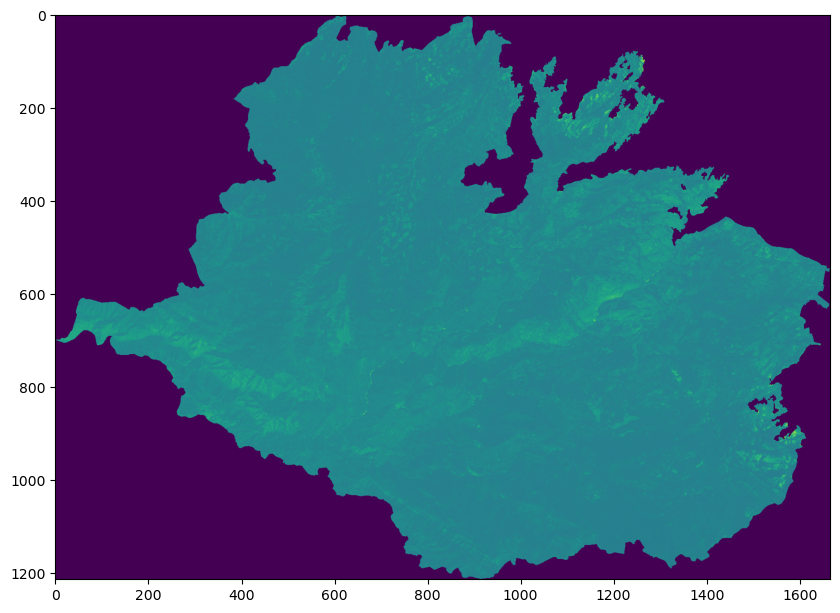

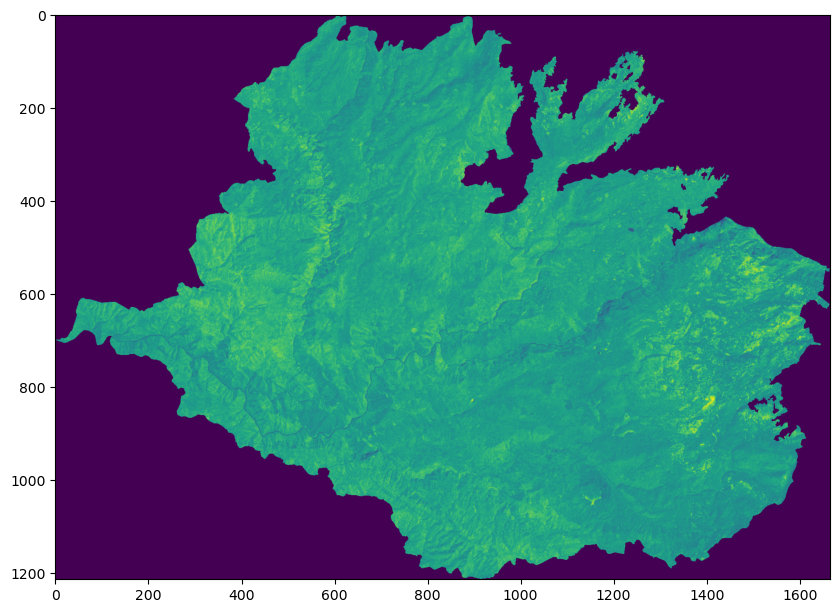

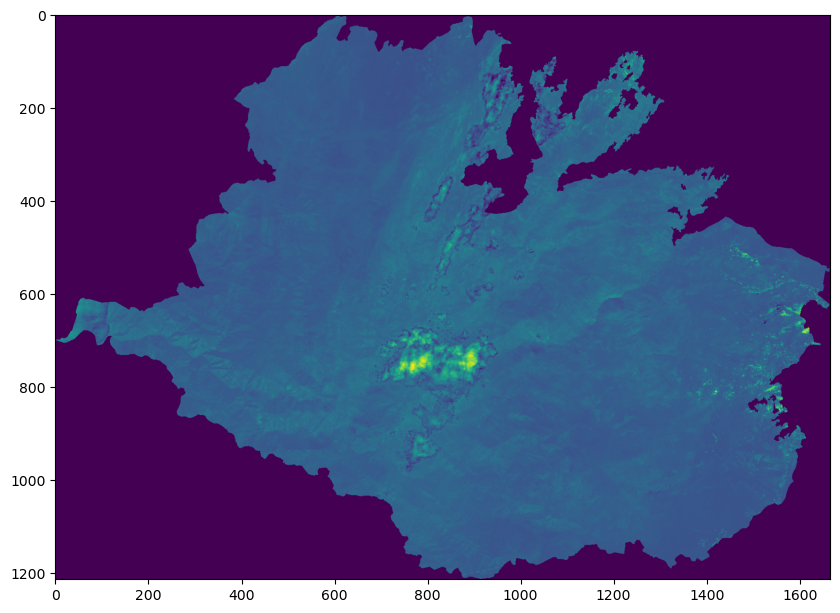

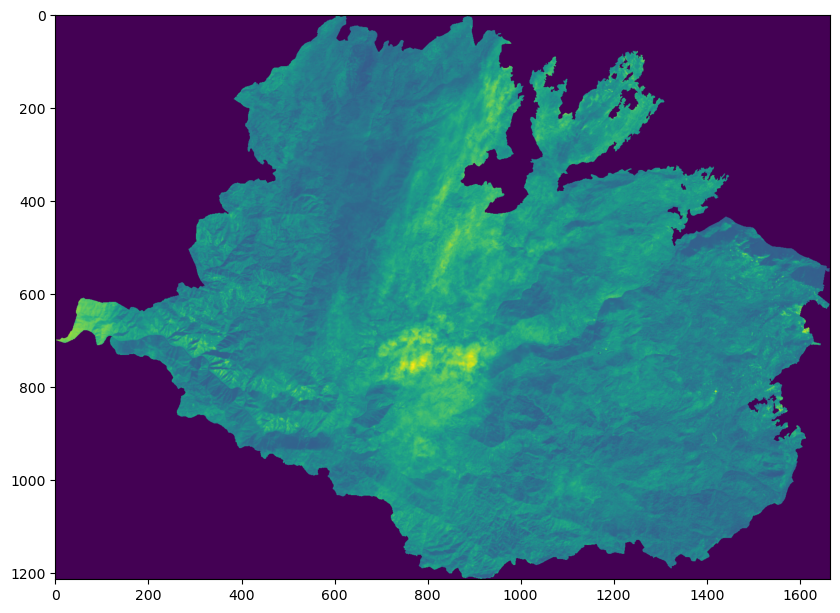

In [39]:

    print(filename)
    clipping(filename)


In [25]:
#open source raster file and extract CRS
with rio.open(parent / folders[0] / dataset[folders[0]][0]) as src:
    crs=src.crs

# Import bounary shapefile and match CRS to that of source data file
boundary = gpd.read_file("C:/RS_GIS/EGM722/Assignment/Test Data/AOI/aoi.shp")
boundary = boundary.to_crs(src.crs)

#fig, ax = plt.subplots(figsize=(10, 10))
#boundary.plot(ax=ax, facecolor = 'none', edgecolor='red', linewidth=2)
#show(data, ax=ax)
#plt.show()

<Axes: >

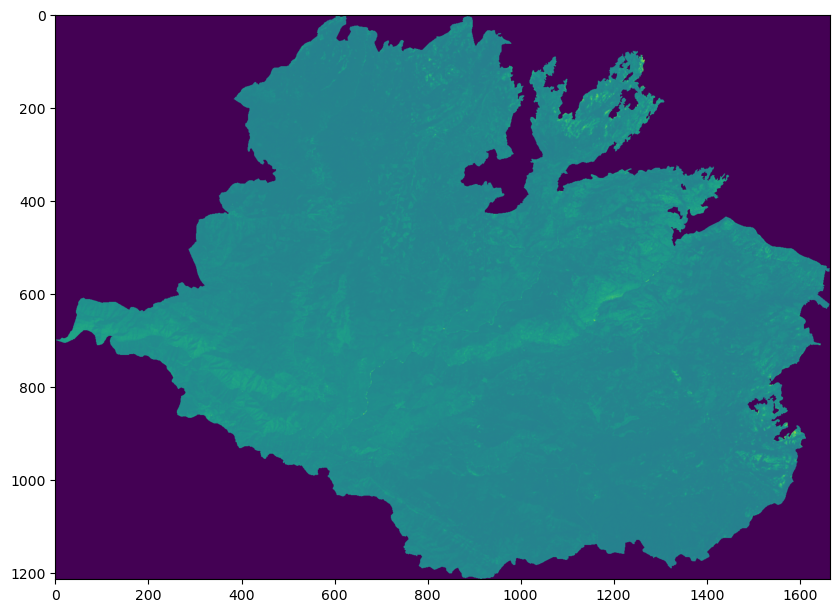

In [17]:
data = rio.open(parent / folders[0] / dataset[folders[0]][0])
geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
out_image, out_transform = mask(data, geom, crop=True)
data.close()

fig, ax2 = plt.subplots(figsize=(10, 10))
show(out_image, ax=ax2)


#    with rio.open(parent / folders[0] / dataset[folders[0]][0]) as data:
#    geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
#    out_image, out_transform = mask(data, geom, crop=True)
#    out_meta = data.meta.copy()
